In [31]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet

def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 0)[0]

In [32]:
from schwingerModel import plotting as sp

sp.setStyle()                          # house rcParams; palette + eb_kw + fmtErr live in sp

# color, marker per GEVP state (marker shape doubles the color, for CVD safety)
stateStyle = list(zip(sp.PALETTE, sp.MARKERS))

def expFit(t, E, logA, t0=0):
    """gevpMassExtract's exponential model in actual-time units: exp(logA - E (t - t0))."""
    return np.exp(logA - E * (t - t0))

In [33]:
paths = ["./configs/beta_30_m0_0.0_Nx_64_Nt_64_melted.hdf5", "./configs/beta_30_m0_0.1_Nx_64_Nt_64_melted.hdf5",
          "./configs/beta_30_m0_0.2_Nx_64_Nt_64_melted.hdf5","./configs/beta_30_m0_0.5_Nx_64_Nt_64_melted.hdf5"]
metas = [sim.distillation.readDistillMeta(p) for p in paths]

In [34]:
basisPion = [triplet(MesonOp("g5")), triplet(MesonOp("g5", DNum=2))]
basisEta = [singlet(MesonOp("g5")), singlet(MesonOp("g5", DNum=2))]

In [35]:
dataPion = [sim.GEVP.measureEnsemble(paths[i], metas[i].configIndices, basisPion) for i in range(len(paths))]
dataEta = [sim.GEVP.measureEnsemble(paths[i], metas[i].configIndices, basisEta) for i in range(len(paths))]

Measuring configs: 100%|██████████| 1000/1000 [00:18<00:00, 55.00it/s]


In [36]:
gevpTi = 2

gevpsPion = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(d, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1)) for d in dataPion)
gevpsEta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(d, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1)) for d in dataEta)

In [51]:
#get lowest masses

fitTsPion = [[10, 20],[10,20],[10,20],[10,20]]
fitTsEta = [[10, 20],[7,20],[5,12],[3,9]]

massesPion = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(dataPion[i], reduce=sim.GEVP.massReduce(ti=gevpTi,shift=1,fitT=fitTsPion[i],withAmp=True)) for i in range(len(dataPion)))
massesEta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(dataEta[i], reduce=sim.GEVP.massReduce(ti=gevpTi,shift=1,fitT=fitTsEta[i],withAmp=True)) for i in range(len(dataEta)))

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 47% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 52% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


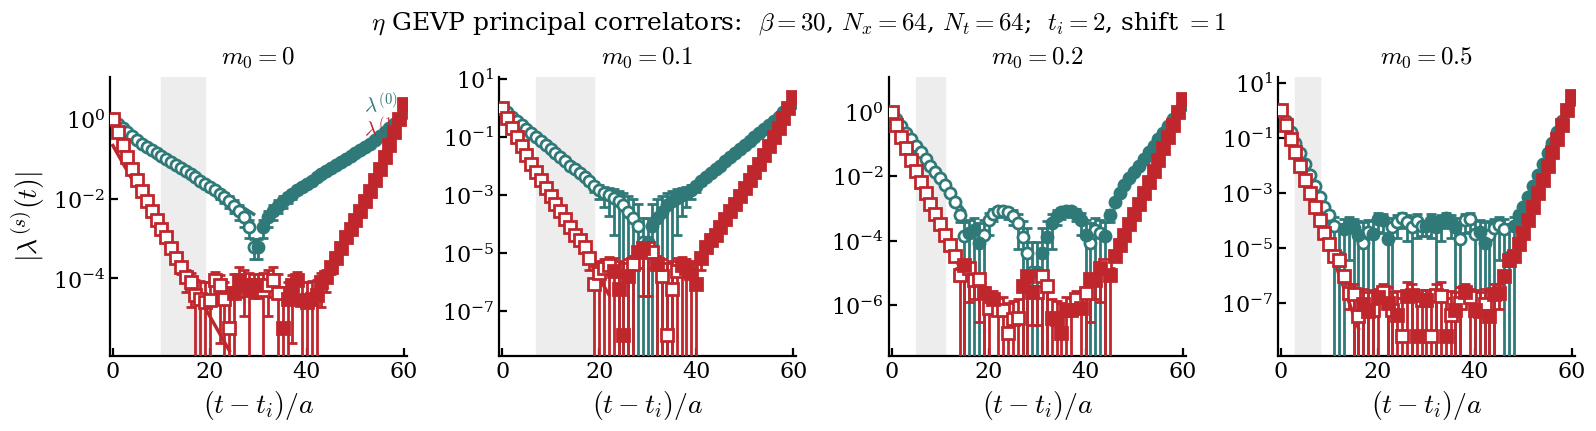

In [61]:
# Raw GEVP eigenvalue curves on a log axis — correlator quality, nothing divided
# out. A clean principal correlator is a straight line here, so early curvature
# (excited-state contamination) and the point where errors swallow the signal
# both read off directly. The fitted exponentials are overlaid across the
# pre-crossing region; a state whose fit returned NaN simply gets no line.
#
# |lambda| is plotted, so the full time extent stays visible. The V dip near
# t = 30 is the sign change: with shift = 1 the correlator C(t+1) - C(t) is
# antisymmetric about T/2 and must cross zero there, i.e. the points really do
# follow a sinh. Markers past the crossing are filled rather than white, so the
# negative branch is marked and not just inferred from the shape.
beta, Nx, Nt = float(metas[0].beta), metas[0].dimx, metas[0].dimt

fig, axes = sp.prinCorrelSemilog(
    gevpsEta, masses=massesEta,
    labels=[rf"$m_0 = {float(m.fMass):g}$" for m in metas],
    fitT=fitTsEta,
    title=(rf"$\eta$ GEVP principal correlators:  $\beta = {beta:g}$, "
           rf"$N_x = {Nx}$, $N_t = {Nt}$;  $t_i = {gevpTi}$, shift $= 1$"),
    savePath=f"figs/etaPrinCorrelSemilog_beta{beta:g}_m0scan_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

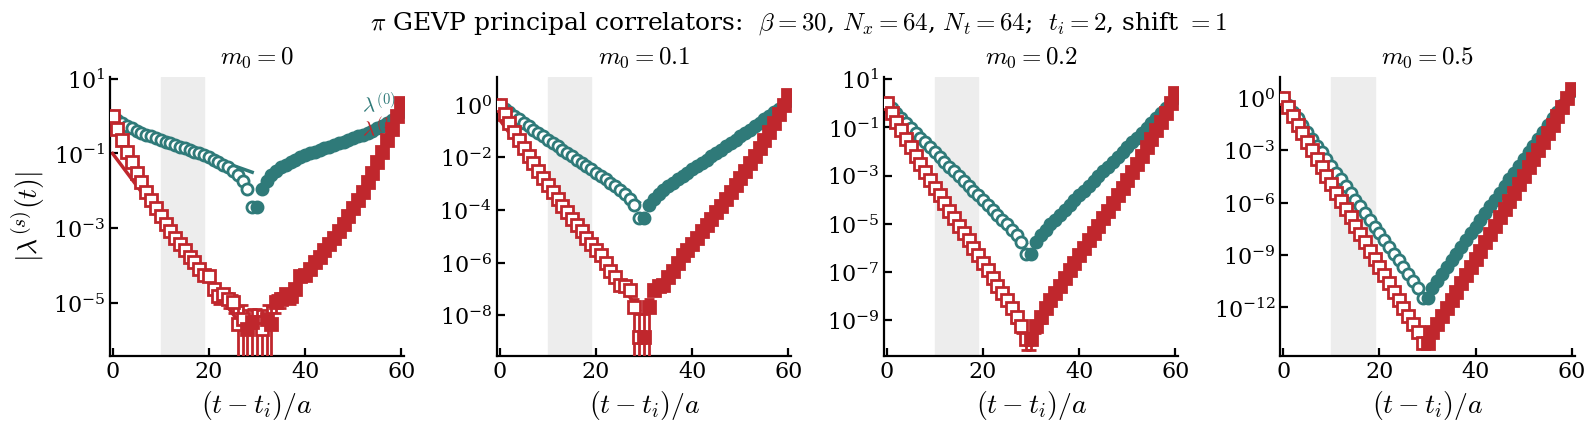

In [62]:
fig, axes = sp.prinCorrelSemilog(
    gevpsPion, masses=massesPion,
    labels=[rf"$m_0 = {float(m.fMass):g}$" for m in metas],
    fitT=fitTsPion,
    title=(rf"$\pi$ GEVP principal correlators:  $\beta = {beta:g}$, "
           rf"$N_x = {Nx}$, $N_t = {Nt}$;  $t_i = {gevpTi}$, shift $= 1$"),
    savePath=f"figs/pionPrinCorrelSemilog_beta{beta:g}_m0scan_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

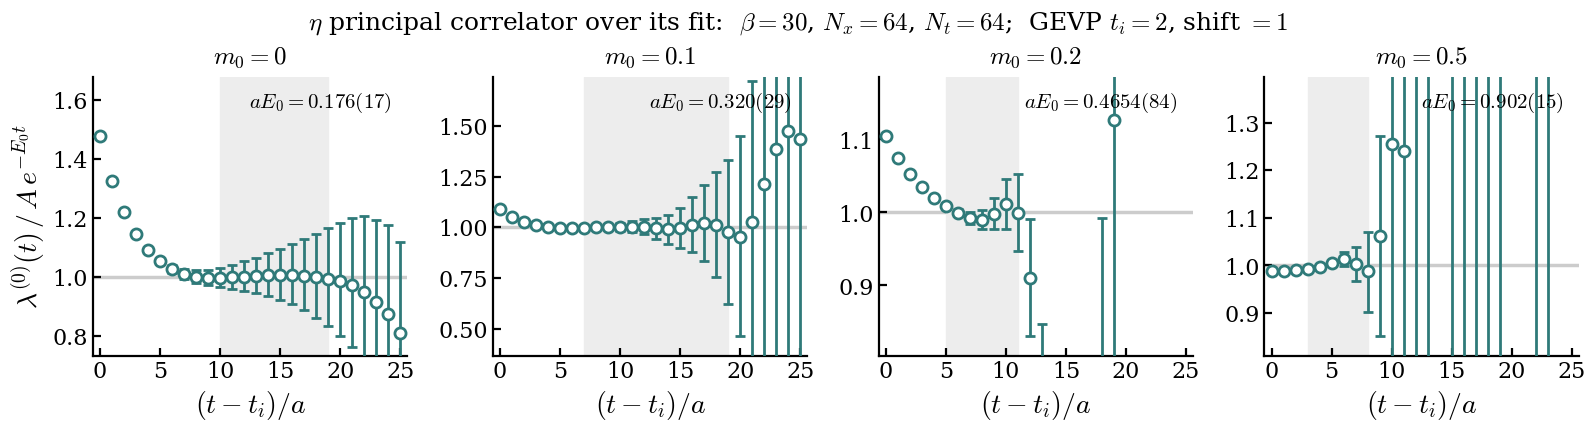

In [63]:
# Ground-state principal correlator over its fit, one panel per quark mass.
# gevps and masses are the bootstrapEnsemble outputs from the two cells above,
# passed straight through — masses needs withAmp=True, which it has.
beta, Nx, Nt = float(metas[0].beta), metas[0].dimx, metas[0].dimt

fig, axes = sp.prinCorrelOverFit(
    gevpsEta, massesEta,
    labels=[rf"$m_0 = {float(m.fMass):g}$" for m in metas],
    state=0, fitT=fitTsEta, tmax=26,
    title=(rf"$\eta$ principal correlator over its fit:  $\beta = {beta:g}$, "
           rf"$N_x = {Nx}$, $N_t = {Nt}$;  GEVP $t_i = {gevpTi}$, shift $= 1$"),
    savePath=f"figs/etaPrinCorrelOverFit_beta{beta:g}_m0scan_Nx{Nx}_Nt{Nt}.pdf")
plt.show()


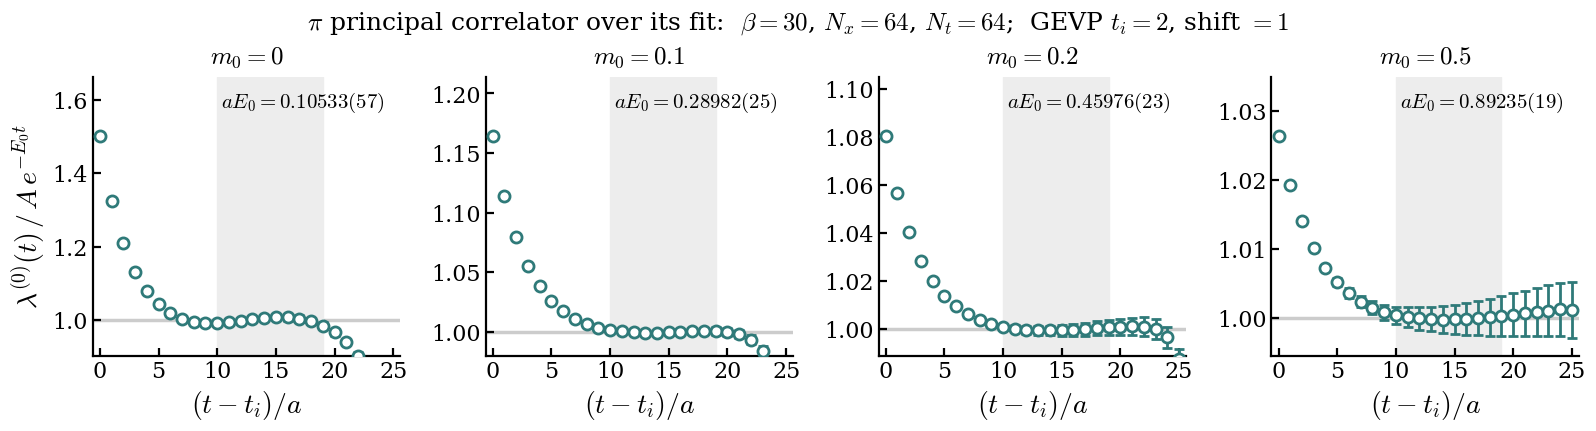

In [64]:
beta, Nx, Nt = float(metas[0].beta), metas[0].dimx, metas[0].dimt

fig, axes = sp.prinCorrelOverFit(
    gevpsPion, massesPion,
    labels=[rf"$m_0 = {float(m.fMass):g}$" for m in metas],
    state=0, fitT=fitTsPion, tmax=26,
    title=(rf"$\pi$ principal correlator over its fit:  $\beta = {beta:g}$, "
           rf"$N_x = {Nx}$, $N_t = {Nt}$;  GEVP $t_i = {gevpTi}$, shift $= 1$"),
    savePath=f"figs/pionPrinCorrelOverFit_beta{beta:g}_m0scan_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

In [65]:
msPion  = np.array([massesPion[i][0][0,0] for i in range(len(paths))])
mfs = np.array([float(metas[i].fMass) for i in range(len(paths))])

# masses[i][1] has shape (2, n_states, 2) = (err rows, state, [E, logA]).
# Index [:, 0, 0] = BOTH err rows for the ground-state ENERGY.
# (masses[i][1][0,0] is [dE, dlogA] from the high row only — that mixes the
#  energy error with the amplitude error into the two yerr slots.)
# Rows are [high-central, central-low]; matplotlib wants [lower, upper].
mErrsPion = np.clip(np.array([massesPion[i][1][:,0,0] for i in range(len(paths))]).T, 0.0, None)
sigPion   = mErrsPion.mean(axis=0)      # symmetrized error, for the fits below

msEta = np.array([massesEta[i][0][0,0] for i in range(len(paths))])
mErrsEta = np.clip(np.array([massesEta[i][1][:,0,0] for i in range(len(paths))]).T, 0.0, None)
sigEta   = mErrsEta.mean(axis=0)      # symmetrized error, for the fits below

In [66]:
# Shared machinery for the mass-vs-quark-mass fits, used by both channels below.
#
# Nf=2 at m << g: M ~ (m^2 mu)^{1/3} with mu = g sqrt(2/pi) the eta scale,
# i.e. M = A m^{2/3}.  Two things bend that here:
#   - Wilson fermions renormalize the quark mass ADDITIVELY, so m0 = 0 is not
#     the chiral point (aM(0) != 0). The fit floats am_c to absorb that.
#   - the law is the leading SMALL-mass behaviour, but these ensembles run to
#     bare m/g = m0 sqrt(beta) = 2.74, well outside m << g.
# So the second fit frees the exponent, to see what the data actually prefer.
# The configs are 50 HMC sweeps apart, so the i.i.d. bootstrap is the right
# estimator and these errors are trustworthy: a large chi^2/dof means the fit
# FORM is failing over this mass range, not that the errors are too small.
from scipy.optimize import curve_fit

law23 = lambda m, A, mc: A * np.abs(m - mc)**(2/3)      # the predicted power
lawP  = lambda m, A, p, mc: A * np.abs(m - mc)**p       # free power, as a test

def band(f, popt, pcov, xs, eps=1e-7):
    """1-sigma error band of f(xs) from the fit covariance, numerical Jacobian."""
    J = np.array([(f(xs, *(np.array(popt) + eps * np.eye(len(popt))[i]))
                   - f(xs, *popt)) / eps for i in range(len(popt))])
    return np.sqrt(np.einsum("ix,ij,jx->x", J, pcov, J))

def massVsQuarkMass(ms, mErrs, sig, symbol, savePath, color=sp.JLab_blue):
    """Fit and plot a ground-state mass against the bare quark mass.

    Args:
        ms: (n,) central masses, one per ensemble (NaN where the fit failed).
        mErrs: (2, n) error rows [high-central, central-low], already clipped.
        sig: (n,) symmetrized error, used for the fits.
        symbol: LaTeX subscript for the state, e.g. r"\\pi" or r"\\eta".
        savePath: Where to write the pdf.
        color: Data colour. Defaults to JLab_blue.

    Returns:
        tuple: (p23, c23, pFree, cFree); fit entries are None when too few
        finite points survive to constrain them.
    """
    # a failed mass fit leaves NaN for that ensemble; curve_fit refuses those
    ok = np.isfinite(ms) & np.isfinite(sig) & (sig > 0)
    if not ok.all():
        print(f"  dropping {int((~ok).sum())} non-finite point(s) at m0 = {mfs[~ok]}")
    x, y, s = mfs[ok], ms[ok], sig[ok]

    def chi2dof(f, popt):
        return np.sum(((y - f(x, *popt)) / s)**2) / max(len(x) - len(popt), 1)

    p23 = c23 = pFree = cFree = None
    if len(x) >= 3:
        p23, c23 = curve_fit(law23, x, y, p0=[1.4, -0.01], sigma=s, absolute_sigma=True)
        print(f"  2/3 law : A = {p23[0]:.4f}, am_c = {p23[1]:.5f}, "
              f"chi2/dof = {chi2dof(law23, p23):.0f}")
    if len(x) >= 4:
        pFree, cFree = curve_fit(lawP, x, y, p0=[p23[0], 2/3, p23[1]], sigma=s,
                                 absolute_sigma=True, maxfev=20000)
        dFree = np.sqrt(np.diag(cFree))
        print(f"  free p  : p = {pFree[1]:.4f} +- {dFree[1]:.4f}, "
              f"chi2/dof = {chi2dof(lawP, pFree):.0f}")

    x0 = p23[1] if p23 is not None else 0.0
    xs = np.linspace(x0, mfs.max() * 1.08, 400)

    fig, ax = plt.subplots(figsize=(7.5, 5.5), layout="constrained")
    ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)

    legendLines = [(rf"$aM_{symbol}$", color)]
    if p23 is not None:
        b23 = band(law23, p23, c23, xs)
        ax.fill_between(xs, law23(xs, *p23) - b23, law23(xs, *p23) + b23,
                        color=sp.JLab_red, alpha=0.20, lw=0, zorder=1)
        ax.plot(xs, law23(xs, *p23), color=sp.JLab_red, lw=sp.LW, zorder=2)
        legendLines.append(
            (rf"$A\,(am_0 - am_c)^{{2/3}}$:  $\chi^2/\mathrm{{dof}} = {chi2dof(law23, p23):.0f}$",
             sp.JLab_red))
    if pFree is not None:
        ax.plot(xs, lawP(xs, *pFree), color=sp.JLab_green, lw=sp.LW, zorder=2)
        legendLines.append(
            (rf"free $p$:  $p = {sp.fmtErr(pFree[1], dFree[1])}$,  "
             rf"$\chi^2/\mathrm{{dof}} = {chi2dof(lawP, pFree):.0f}$", sp.JLab_green))

    ax.errorbar(mfs[ok], ms[ok], yerr=mErrs[::-1][:, ok], marker="o",
                color=color, mec=color, **sp.eb_kw)

    ax.set_xlim(x0 - 0.02, mfs.max() * 1.08)
    ax.set_ylim(bottom=-0.03)
    if p23 is not None:
        # open-circle tick marking the fitted chiral point on the mass axis
        ax.plot([p23[1]], [ax.get_ylim()[0]], marker="o", ms=9, mfc="white",
                mec="0.4", mew=2.0, clip_on=False, zorder=4)

    for j, (txt, col) in enumerate(legendLines):
        ax.text(0.03, 0.95 - 0.075 * j, txt, color=col, ha="left", va="top",
                transform=ax.transAxes, fontsize=15, zorder=5, bbox=sp.TEXTBOX)

    ax.set_xlabel(r"$a m_0$")
    ax.set_ylabel(rf"$a M_{symbol}$")
    ax.set_title(rf"$M_{symbol}$ vs quark mass:  $\beta = {beta:g}$, "
                 rf"$N_x = {Nx}$, $N_t = {Nt}$", fontsize=17, pad=10)
    fig.savefig(savePath)
    plt.show()
    return p23, c23, pFree, cFree

print(f"bare m/g = {mfs * np.sqrt(beta)}")

bare m/g = [0.         0.54772256 1.09544512 2.73861279]


pion:
  2/3 law : A = 1.3851, am_c = -0.00594, chi2/dof = 16819
  free p  : p = 0.8188 +- 0.0013, chi2/dof = 283


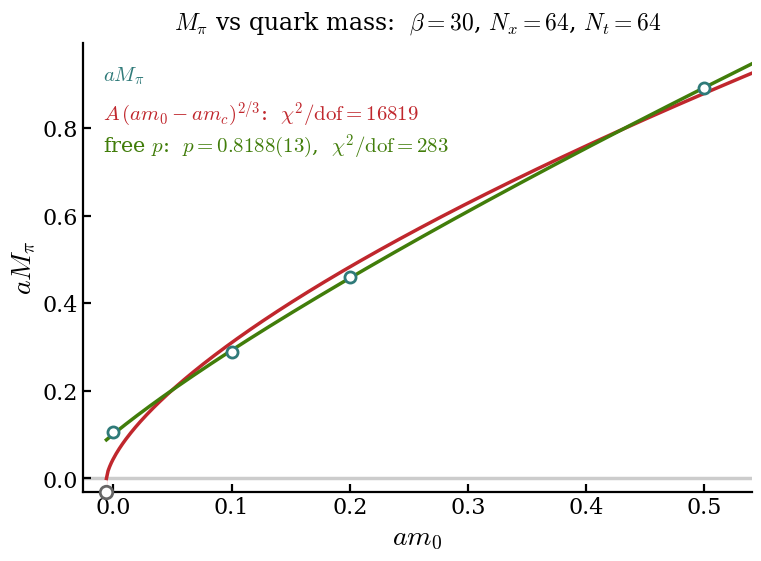

In [67]:
# Pion (isotriplet): massless in the chiral limit, so the 2/3 law applies here.
print("pion:")
p23Pion, c23Pion, pFreePion, cFreePion = massVsQuarkMass(
    msPion, mErrsPion, sigPion, r"\pi",
    f"figs/pionMassVsQuarkMass_beta{beta:g}_Nx{Nx}_Nt{Nt}.pdf",
    color=sp.JLab_blue)

eta:
  2/3 law : A = 1.2936, am_c = -0.03582, chi2/dof = 14
  free p  : p = 1.0106 +- 0.1044, chi2/dof = 0


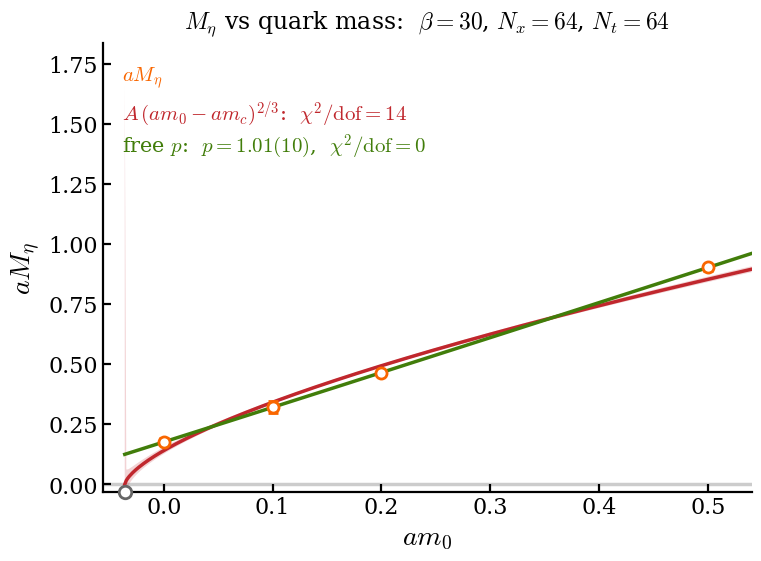

In [68]:
# Eta (isosinglet): the anomaly keeps it massive as m0 -> 0, so it does NOT
# vanish at the chiral point and the 2/3 law does not apply. The fits are drawn
# for comparison with the pion, not because the form is predicted here.
print("eta:")
p23Eta, c23Eta, pFreeEta, cFreeEta = massVsQuarkMass(
    msEta, mErrsEta, sigEta, r"\eta",
    f"figs/etaMassVsQuarkMass_beta{beta:g}_Nx{Nx}_Nt{Nt}.pdf",
    color=sp.JLab_orange)

  m0 = 0.00:  aM_eta - aM_pi = 0.071(16)
  m0 = 0.10:  aM_eta - aM_pi = 0.030(26)
  m0 = 0.20:  aM_eta - aM_pi = 0.0056(83)
  m0 = 0.50:  aM_eta - aM_pi = 0.010(15)
chiral-limit prediction  a mu = sqrt(2/pi)/sqrt(beta) = 0.14567


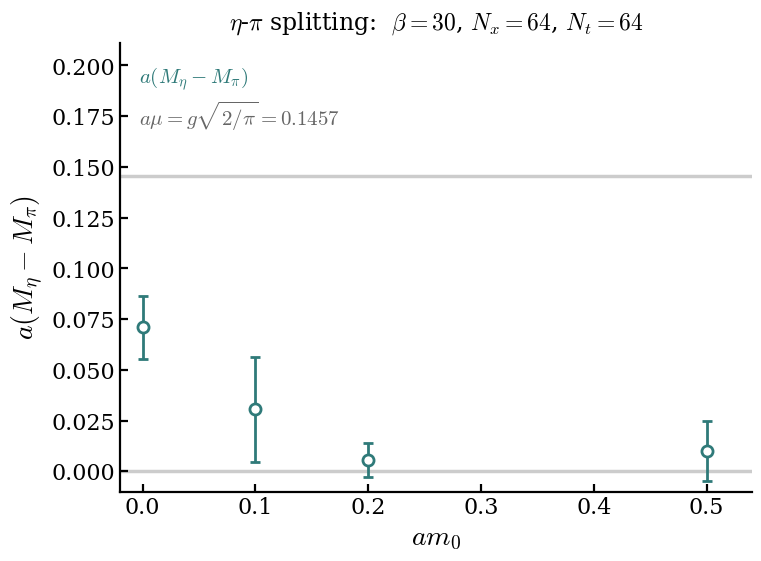

In [69]:
# Eta-pion splitting. The anomaly gives the isosinglet a mass that survives the
# chiral limit while the pion's vanishes, so as m0 -> the chiral point the
# splitting should approach the Schwinger boson scale
#     a mu = a g sqrt(2/pi) = sqrt(2/pi) / sqrt(beta)
# (theory.py's etaMass), drawn as the grey line. That is a parameter-free
# prediction, and it is the m -> 0 statement only: at these quark masses both
# states are heavy and the splitting need not sit on it.
#
# CAVEAT on the errors: massesPion and massesEta come from two SEPARATE
# bootstrapEnsemble calls, each with its own rng draw (seed=None), so the
# resamples are not aligned and the pion/eta covariance is unavailable. Adding
# in quadrature assumes they are independent. They share gauge configs and so
# are almost certainly positively correlated, which makes these bars an
# OVERestimate. A correct splitting error needs both masses evaluated on the
# same resamples.
mu = np.sqrt(2 / np.pi) / np.sqrt(beta)

diff    = msEta - msPion
sigDiff = np.sqrt(sigPion**2 + sigEta**2)
ok      = np.isfinite(diff) & np.isfinite(sigDiff)
if not ok.all():
    print(f"dropping {int((~ok).sum())} point(s) with a failed fit at m0 = {mfs[~ok]}")
for i in np.nonzero(ok)[0]:
    print(f"  m0 = {mfs[i]:.2f}:  aM_eta - aM_pi = {sp.fmtErr(diff[i], sigDiff[i])}")
print(f"chiral-limit prediction  a mu = sqrt(2/pi)/sqrt(beta) = {mu:.5f}")

fig, ax = plt.subplots(figsize=(7.5, 5.5), layout="constrained")
ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.axhline(mu, color=sp.GREY, lw=sp.LW, zorder=0)      # Schwinger boson scale

ax.errorbar(mfs[ok], diff[ok], yerr=sigDiff[ok], marker="o",
            color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)

ax.set_xlim(-0.02, mfs.max() * 1.08)
# headroom above whichever is higher, mu or the data, so the legend block does
# not land on the grey mu line
top = max(mu, np.nanmax((diff + sigDiff)[ok])) if ok.any() else mu
ax.set_ylim(-0.01, top * 1.45)

legendLines = [(r"$a(M_\eta - M_\pi)$", sp.JLab_blue),
               (rf"$a\mu = g\sqrt{{2/\pi}} = {mu:.4f}$", "0.4")]
for j, (txt, col) in enumerate(legendLines):
    ax.text(0.03, 0.95 - 0.075 * j, txt, color=col, ha="left", va="top",
            transform=ax.transAxes, fontsize=15, zorder=5, bbox=sp.TEXTBOX)

ax.set_xlabel(r"$a m_0$")
ax.set_ylabel(r"$a(M_\eta - M_\pi)$")
ax.set_title(rf"$\eta$-$\pi$ splitting:  $\beta = {beta:g}$, "
             rf"$N_x = {Nx}$, $N_t = {Nt}$", fontsize=17, pad=10)

fig.savefig(f"figs/etaPionSplitting_beta{beta:g}_Nx{Nx}_Nt{Nt}.pdf")
plt.show()

  m0 = 0.00:  R = 0.67(15)   below 2M_pi (stable)
  m0 = 0.10:  R = 0.105(89)   below 2M_pi (stable)
  m0 = 0.20:  R = 0.012(18)   below 2M_pi (stable)
  m0 = 0.50:  R = 0.011(16)   below 2M_pi (stable)


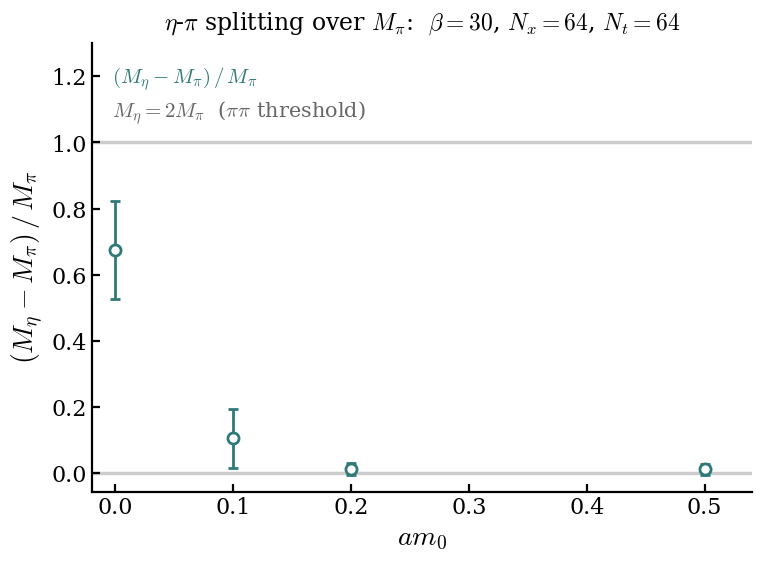

In [70]:
# Splitting in units of the pion mass: R = (M_eta - M_pi)/M_pi = M_eta/M_pi - 1.
#
# The point of this normalisation is the threshold at R = 1, which is exactly
# M_eta = 2 M_pi. Above that line the eta is kinematically able to go to two
# pions, so it is a RESONANCE rather than a stable state, and a single-
# exponential mass out of a two-operator GEVP stops being the right description
# of it. Below the line it is stable and the extracted mass is a real gap.
#
# The chiral end is where this bites: M_pi ~ m^{2/3} -> 0 while M_eta -> mu, so
# R -> infinity as m -> 0. Raising the quark mass pushes M_pi up until
# 2 M_pi > M_eta and the eta drops below threshold; the crossing is somewhere in
# between, which is what this plot is for.
#
# Two caveats:
#  - R = 1 is KINEMATICS only. Whether eta -> pi pi actually proceeds depends on
#    parity/G-parity selection rules in 2d; theory.py works the analogous case
#    for the scalar sigma, which is stable because M_sigma = sqrt(3) M_pi sits
#    below 2 M_pi for every theta.
#  - the errors again assume pion/eta independence (see the cell above). That
#    approximation is WORSE for a ratio than for a difference: correlated errors
#    partly cancel in M_eta/M_pi, so the true bars should be tighter still.
ratio = msEta / msPion - 1.0
# dR = (M_eta/M_pi) sqrt( (sig_eta/M_eta)^2 + (sig_pi/M_pi)^2 ), uncorrelated
sigRatio = np.abs(msEta / msPion) * np.sqrt((sigEta / msEta)**2 + (sigPion / msPion)**2)
okR = np.isfinite(ratio) & np.isfinite(sigRatio)
if not okR.all():
    print(f"dropping {int((~okR).sum())} point(s) with a failed fit at m0 = {mfs[~okR]}")
for i in np.nonzero(okR)[0]:
    flag = "above 2M_pi (resonance)" if ratio[i] > 1 else "below 2M_pi (stable)"
    print(f"  m0 = {mfs[i]:.2f}:  R = {sp.fmtErr(ratio[i], sigRatio[i])}   {flag}")

fig, ax = plt.subplots(figsize=(7.5, 5.5), layout="constrained")
ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.axhline(1.0, color=sp.GREY, lw=sp.LW, zorder=0)     # M_eta = 2 M_pi threshold

ax.errorbar(mfs[okR], ratio[okR], yerr=sigRatio[okR], marker="o",
            color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)

ax.set_xlim(-0.02, mfs.max() * 1.08)
top = max(1.0, np.nanmax((ratio + sigRatio)[okR])) if okR.any() else 1.0
bot = min(0.0, np.nanmin((ratio - sigRatio)[okR])) if okR.any() else 0.0
ax.set_ylim(bot - 0.05 * (top - bot), top + 0.30 * (top - bot))

legendLines = [(r"$(M_\eta - M_\pi)\,/\,M_\pi$", sp.JLab_blue),
               (r"$M_\eta = 2M_\pi$  ($\pi\pi$ threshold)", "0.4")]
for j, (txt, col) in enumerate(legendLines):
    ax.text(0.03, 0.95 - 0.075 * j, txt, color=col, ha="left", va="top",
            transform=ax.transAxes, fontsize=15, zorder=5, bbox=sp.TEXTBOX)

ax.set_xlabel(r"$a m_0$")
ax.set_ylabel(r"$(M_\eta - M_\pi)\,/\,M_\pi$")
ax.set_title(rf"$\eta$-$\pi$ splitting over $M_\pi$:  $\beta = {beta:g}$, "
             rf"$N_x = {Nx}$, $N_t = {Nt}$", fontsize=17, pad=10)

fig.savefig(f"figs/etaPionSplittingOverPion_beta{beta:g}_Nx{Nx}_Nt{Nt}.pdf")
plt.show()